In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("../data/HR_Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [6]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
attrition_rate = (df['Attrition'].value_counts()['Yes'] / len(df)) * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

categorical_cols = df.select_dtypes(include='object').columns

print("Numeric Columns:", len(numeric_cols))
print("Categorical Columns:", len(categorical_cols))

Numeric Columns: 26
Categorical Columns: 9


In [9]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

Observation:

The dataset shows that employee attrition is imbalanced because the number of employees who stayed is much higher than employees who left. This means the model needs to handle class imbalance while training to correctly identify employees at risk of leaving.

In [10]:
df = df.drop([
    'EmployeeNumber',
    'EmployeeCount',
    'Over18',
    'StandardHours'
], axis=1)

df.shape

(1470, 31)

In [11]:
df['Attrition'] = df['Attrition'].map({
    'Yes':1,
    'No':0
})

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [12]:
X = df.drop('Attrition', axis=1)

y = df['Attrition']

In [13]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [14]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


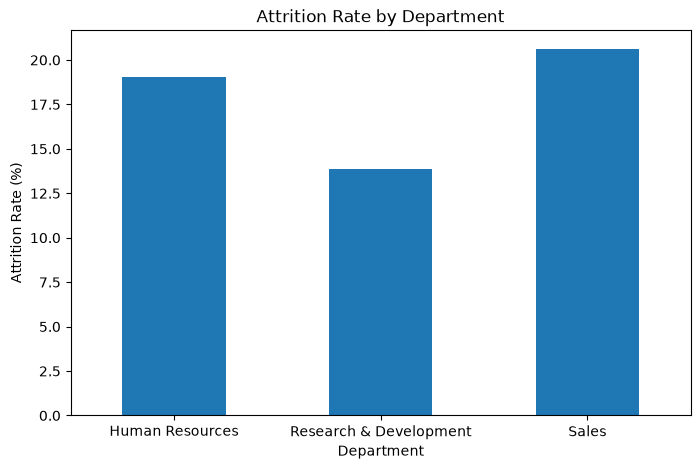

In [15]:
dept_attrition = df.groupby('Department')['Attrition'].mean()*100

plt.figure(figsize=(8,5))

dept_attrition.plot(kind='bar')

plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Department")

plt.xticks(rotation=0)

plt.savefig("../charts/department_attrition.png",
            bbox_inches='tight')

plt.show()

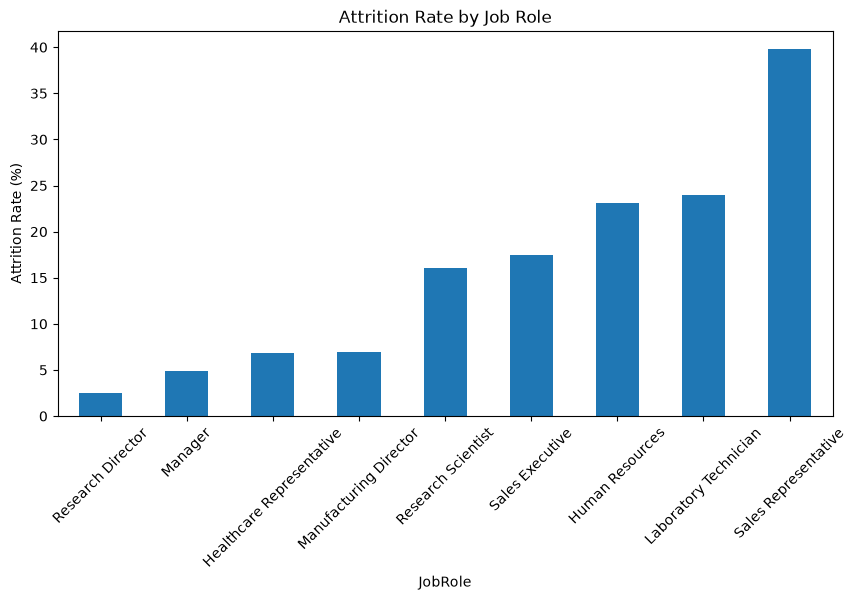

In [16]:
role_attrition = df.groupby('JobRole')['Attrition'].mean()*100


plt.figure(figsize=(10,5))

role_attrition.sort_values().plot(kind='bar')


plt.ylabel("Attrition Rate (%)")
plt.title("Attrition Rate by Job Role")


plt.xticks(rotation=45)

plt.savefig("../charts/jobrole_attrition.png",
            bbox_inches='tight')

plt.show()

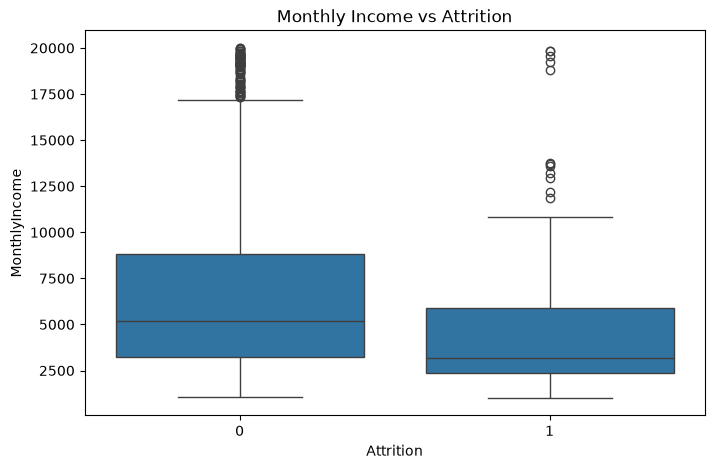

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.savefig("../charts/income_attrition.png",
            bbox_inches='tight')

plt.show()

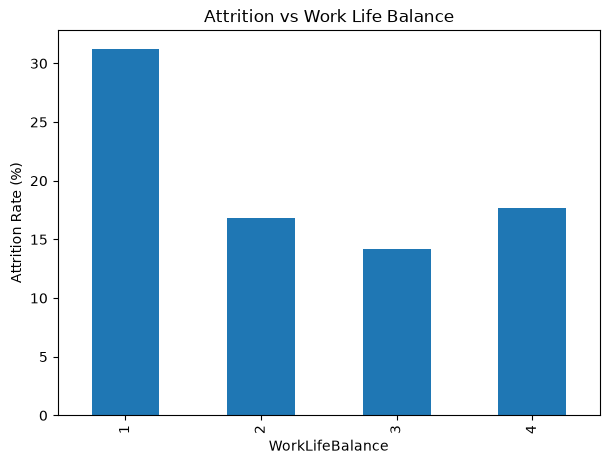

In [18]:
wlb = df.groupby('WorkLifeBalance')['Attrition'].mean()*100


plt.figure(figsize=(7,5))

wlb.plot(kind='bar')


plt.ylabel("Attrition Rate (%)")
plt.title("Attrition vs Work Life Balance")


plt.savefig("../charts/worklife_balance.png",
            bbox_inches='tight')

plt.show()

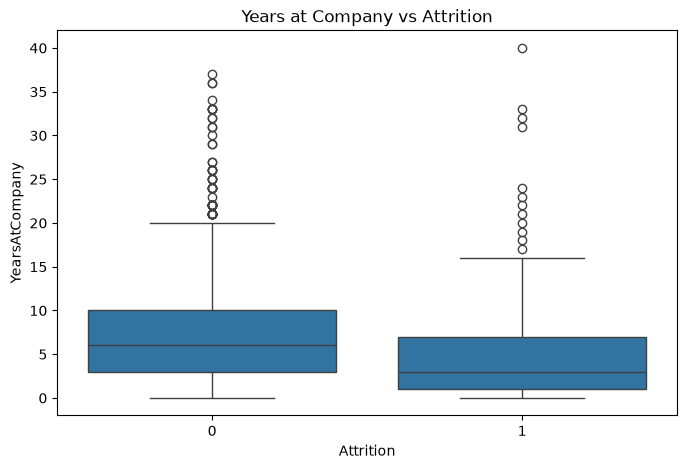

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=df
)

plt.title("Years at Company vs Attrition")


plt.savefig("../charts/years_company.png",
            bbox_inches='tight')

plt.show()

In [20]:
dept_attrition

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64

In [21]:
role_attrition.sort_values(ascending=False).head()

JobRole
Sales Representative     39.759036
Laboratory Technician    23.938224
Human Resources          23.076923
Sales Executive          17.484663
Research Scientist       16.095890
Name: Attrition, dtype: float64

Business Insights:

1. Sales department has the highest attrition rate at around 20.63%, indicating that employees in sales roles may require stronger retention strategies.

2. Sales Representatives show the highest exit rate (39.76%), making this role a priority for HR retention programs.

3. Employees in lower salary ranges appear more likely to leave, suggesting compensation and growth opportunities may influence employee retention.

4. Employees with lower work-life balance scores show higher attrition, highlighting the importance of employee wellbeing programs.

5. Employees with shorter tenure at the company have a higher chance of leaving, suggesting early career engagement and onboarding improvements can reduce attrition.

In [22]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


In [23]:
models = {

"Logistic Regression": LogisticRegression(
    class_weight='balanced',
    max_iter=1000
),

"Random Forest": RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
),

"Gradient Boosting": GradientBoostingClassifier()

}

In [24]:
results = []


for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    auc = roc_auc_score(
        y_test,
        model.predict_proba(X_test)[:,1]
    )

    results.append([
        name,
        auc
    ])


results_df = pd.DataFrame(
    results,
    columns=["Model","ROC-AUC"]
)


results_df

,Model,ROC-AUC
0,Logistic Regression,0.798605
1,Random Forest,0.778577
2,Gradient Boosting,0.794814


In [25]:
best_model = models["Logistic Regression"]

y_pred = best_model.predict(X_test)

In [26]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.91      0.77      0.84       247
           1       0.34      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.77       294



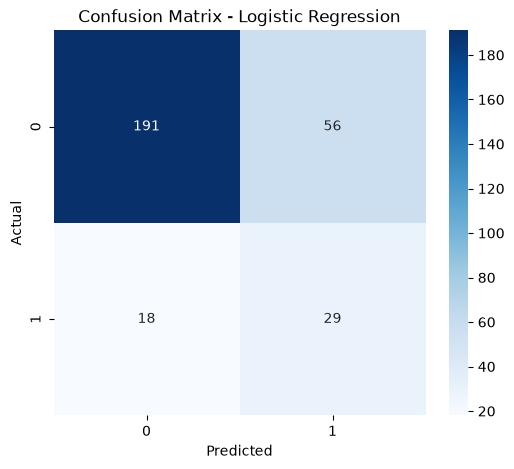

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)


plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix - Logistic Regression")


plt.savefig(
    "../charts/confusion_matrix.png",
    bbox_inches='tight'
)

plt.show()

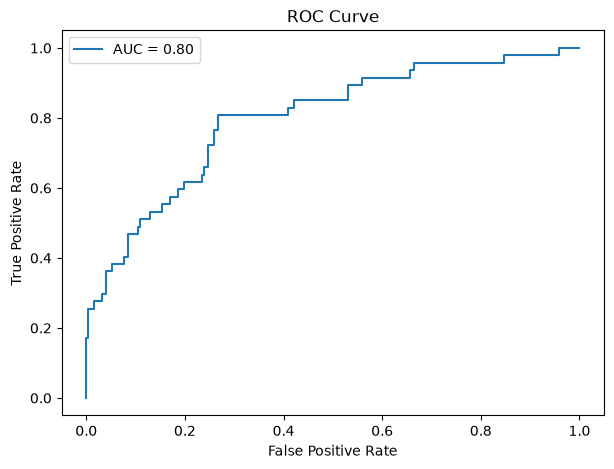

In [28]:
y_prob = best_model.predict_proba(X_test)[:,1]


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)


plt.figure(figsize=(7,5))


plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc_score(y_test,y_prob):.2f}"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")


plt.legend()


plt.savefig(
    "../charts/roc_curve.png",
    bbox_inches='tight'
)


plt.show()

In [29]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": abs(best_model.coef_[0])

})


importance = importance.sort_values(
    "Importance",
    ascending=False
)


importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.797874
43,OverTime_Yes,0.766412
23,BusinessTravel_Travel_Frequently,0.719335
7,JobLevel,0.659189
16,TotalWorkingYears,0.656931
40,JobRole_Sales Representative,0.552515
24,BusinessTravel_Travel_Rarely,0.511649
27,EducationField_Life Sciences,0.506505
21,YearsSinceLastPromotion,0.500389
26,Department_Sales,0.481690


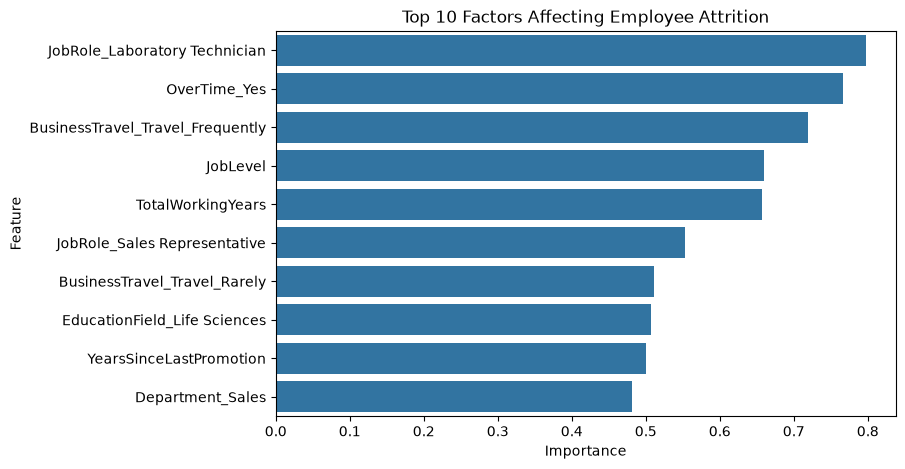

In [30]:
plt.figure(figsize=(8,5))


sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)


plt.title(
    "Top 10 Factors Affecting Employee Attrition"
)


plt.savefig(
    "../charts/feature_importance.png",
    bbox_inches='tight'
)


plt.show()

Model Insights:

The Logistic Regression model achieved the best performance with a ROC-AUC score of 0.80. The model identified important factors influencing employee attrition such as overtime, job role, business travel frequency, job level, and total working years.

Employees working overtime and employees in certain job roles like Sales Representative and Laboratory Technician showed higher chances of leaving. These insights can help HR teams create targeted retention strategies.

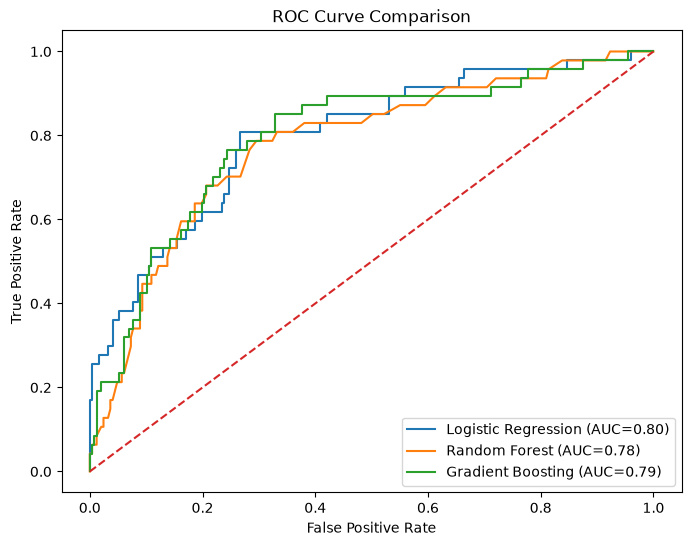

In [31]:
from sklearn.metrics import roc_curve, auc


plt.figure(figsize=(8,6))


for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr,tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.2f})"
    )


plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve Comparison")


plt.legend()


plt.savefig(
    "../charts/roc_curve_comparison.png",
    bbox_inches="tight"
)


plt.show()

HR Insights & Business Recommendations:

The model identified overtime, job role, business travel frequency, and job level as important factors influencing employee attrition. Employees working overtime and employees in roles such as Sales Representative and Laboratory Technician showed higher chances of leaving. The Sales department should be prioritized for retention efforts because it has the highest attrition rate of around 20.63%. Salary alone does not explain employee exits; factors like workload, career growth, job satisfaction, and work-life balance also strongly influence decisions. HR teams can reduce attrition by improving workload management and conducting early retention discussions with high-risk employees. The company should provide better career development opportunities and monitor employees with high overtime and low satisfaction levels. One limitation of this model is that it is based on historical employee data, so predictions should support HR decisions rather than replace human judgement.